# Monte Carlo Simulation for Option Pricing & Portfolio Risk

**Author:** Lenny  
**Date:** March 2026

---

## 1. Introduction

This notebook develops a Monte Carlo simulation framework for two core problems in quantitative finance:

1. **European option pricing** under the risk-neutral measure, benchmarked against the Black–Scholes closed-form solution.
2. **Portfolio risk measurement** via Value-at-Risk (VaR) and Expected Shortfall (ES) computed from simulated return distributions.

Monte Carlo methods are indispensable in modern finance. While the Black–Scholes formula provides an exact solution for vanilla European options, Monte Carlo simulation extends naturally to settings where no analytical solution exists — exotic payoffs, path-dependent options, stochastic volatility, and multi-asset portfolios.

The notebook is structured as follows:

| Section | Topic |
|---|---|
| 2 | Financial theory — GBM and Monte Carlo intuition |
| 3 | Simulation setup and parameter specification |
| 4 | Simulating stock price paths |
| 5 | Option pricing via Monte Carlo |
| 6 | Portfolio Value-at-Risk simulation |
| 7 | Visualisations and results |


## 2. Financial Theory

### 2.1 Geometric Brownian Motion

The standard model for equity prices in continuous time is Geometric Brownian Motion (GBM). Under the physical measure, the stock price $S(t)$ satisfies:

$$dS = \mu \, S \, dt + \sigma \, S \, dW_t$$

where $\mu$ is the expected drift, $\sigma$ is the volatility, and $W_t$ is a standard Brownian motion.

For **derivative pricing**, we work under the *risk-neutral* measure $\mathbb{Q}$, replacing $\mu$ with the risk-free rate $r$:

$$dS = r \, S \, dt + \sigma \, S \, dW_t^{\mathbb{Q}}$$

Applying Itô's lemma to $\ln S(t)$ yields the exact solution:

$$S(t + \Delta t) = S(t) \cdot \exp\!\left[\left(r - \frac{\sigma^2}{2}\right)\Delta t + \sigma \sqrt{\Delta t}\; Z\right], \quad Z \sim \mathcal{N}(0,1)$$

This is computationally convenient: each time step requires only a single draw from a standard normal, and the exponential form guarantees $S > 0$.

### 2.2 Monte Carlo Pricing Intuition

The fundamental theorem of asset pricing tells us that the fair value of a European derivative with payoff $g(S_T)$ is:

$$V_0 = e^{-rT}\;\mathbb{E}^{\mathbb{Q}}[g(S_T)]$$

Monte Carlo replaces this expectation with a sample average. We:

1. Simulate $N$ independent paths of $S$ under $\mathbb{Q}$.
2. Evaluate the payoff $g(S_T^{(i)})$ for each path.
3. Discount and average:

$$\hat{V}_0 = e^{-rT}\;\frac{1}{N}\sum_{i=1}^{N} g\!\left(S_T^{(i)}\right)$$

By the **Strong Law of Large Numbers**, $\hat{V}_0 \xrightarrow{\text{a.s.}} V_0$ as $N \to \infty$.

By the **Central Limit Theorem**, the estimation error is approximately normal with standard error $\text{SE} = \hat{\sigma}_g / \sqrt{N}$, giving a convergence rate of $\mathcal{O}(1/\sqrt{N})$.

### 2.3 Black–Scholes Benchmark

For a European call with strike $K$:

$$C = S_0 \, \Phi(d_1) - K \, e^{-rT}\,\Phi(d_2)$$

$$d_1 = \frac{\ln(S_0/K) + (r + \sigma^2/2)\,T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}$$

We will use this closed-form price as a ground-truth reference.

### 2.4 Risk Measures

**Value-at-Risk** at confidence $\alpha$:

$$\text{VaR}_\alpha = -Q_\alpha(R)$$

**Expected Shortfall** (Conditional VaR):

$$\text{ES}_\alpha = -\mathbb{E}[R \mid R \leq Q_\alpha(R)]$$

ES is a *coherent* risk measure — it satisfies sub-additivity — and is preferred by regulators under Basel III/IV.


## 3. Simulation Setup

We begin by importing dependencies and defining the model parameters. All monetary values are in USD.


In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# Add project root to path so we can import our modules
sys.path.insert(0, os.path.abspath('..'))

from src.simulation import simulate_gbm_paths, generate_time_grid
from src.pricing import (
    black_scholes_call, black_scholes_put,
    monte_carlo_european_call, monte_carlo_european_put,
    convergence_analysis,
)
from src.risk_metrics import (
    simulate_portfolio_returns, historical_var,
    historical_expected_shortfall, compute_risk_summary,
)

# Plotting style
plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

print("Setup complete.")


Setup complete.


In [2]:
# ── Model parameters ──────────────────────────────────────────────
S0    = 100.0       # Initial stock price ($)
K     = 105.0       # Strike price ($)
r     = 0.05        # Risk-free rate (5 %)
sigma = 0.20        # Annualised volatility (20 %)
T     = 1.0         # Time horizon (1 year)

# ── Simulation parameters ────────────────────────────────────────
n_steps       = 252          # Daily time steps
n_simulations = 100_000      # Number of Monte Carlo paths
seed          = 42           # Reproducibility

# ── Portfolio parameters ─────────────────────────────────────────
portfolio_value = 1_000_000  # Notional ($)

print(f"S₀ = ${S0}  |  K = ${K}  |  r = {r:.1%}  |  σ = {sigma:.0%}  |  T = {T} yr")
print(f"Paths = {n_simulations:,}  |  Steps/path = {n_steps}")


S₀ = $100.0  |  K = $105.0  |  r = 5.0%  |  σ = 20%  |  T = 1.0 yr
Paths = 100,000  |  Steps/path = 252


## 4. Simulating Stock Price Paths

Using the exact log-normal discretisation of GBM, we generate `n_simulations` independent paths, each with `n_steps` time steps.


In [3]:
paths = simulate_gbm_paths(S0, r, sigma, T, n_steps, n_simulations, seed=seed)
t_grid = generate_time_grid(T, n_steps)

print(f"Path matrix shape: {paths.shape}  (simulations × time steps)")
print(f"Sample terminal prices: {paths[:5, -1].round(2)}")


Path matrix shape: (100000, 253)  (simulations × time steps)
Sample terminal prices: [ 88.38 110.67  76.35 105.02  97.9 ]


### 4.1 Visualisation — Simulated Price Paths

We plot a random subset of paths together with the mean trajectory. The fan-shaped dispersion reflects the role of $\sigma$.


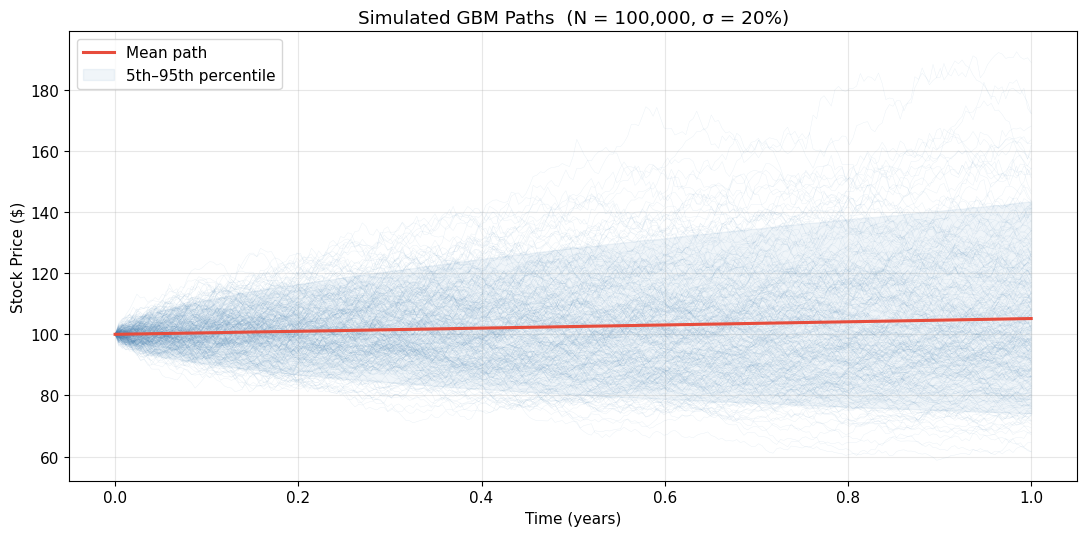

In [4]:
fig, ax = plt.subplots(figsize=(11, 5.5))

n_show = 300
for i in range(n_show):
    ax.plot(t_grid, paths[i], lw=0.3, alpha=0.12, color='steelblue')

mean_path = paths.mean(axis=0)
ax.plot(t_grid, mean_path, lw=2.2, color='#E74C3C', label='Mean path')

# Percentile bands
p5  = np.percentile(paths, 5, axis=0)
p95 = np.percentile(paths, 95, axis=0)
ax.fill_between(t_grid, p5, p95, alpha=0.08, color='steelblue', label='5th–95th percentile')

ax.set_xlabel('Time (years)')
ax.set_ylabel('Stock Price ($)')
ax.set_title(f'Simulated GBM Paths  (N = {n_simulations:,}, σ = {sigma:.0%})')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('../plots/price_paths.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Option Pricing Using Monte Carlo

### 5.1 Black–Scholes Reference

We first compute the closed-form prices as benchmarks.


In [5]:
bs_call = black_scholes_call(S0, K, r, sigma, T)
bs_put  = black_scholes_put(S0, K, r, sigma, T)

print(f"Black–Scholes call price:  ${bs_call:.4f}")
print(f"Black–Scholes put  price:  ${bs_put:.4f}")
print(f"\nPut–call parity check: C − P = {bs_call - bs_put:.4f}  "
      f"vs  S₀ − K·e^{{-rT}} = {S0 - K * np.exp(-r*T):.4f}")


Black–Scholes call price:  $8.0214
Black–Scholes put  price:  $7.9004

Put–call parity check: C − P = 0.1209  vs  S₀ − K·e^{-rT} = 0.1209


### 5.2 Monte Carlo Estimates

In [6]:
terminal = paths[:, -1]

mc_call = monte_carlo_european_call(terminal, K, r, T)
mc_put  = monte_carlo_european_put(terminal, K, r, T)

print(f"MC call price:  ${mc_call['price']:.4f}  (SE = ${mc_call['std_error']:.4f})")
print(f"MC put  price:  ${mc_put['price']:.4f}  (SE = ${mc_put['std_error']:.4f})")
print(f"\nCall pricing error: ${abs(mc_call['price'] - bs_call):.4f}  "
      f"({abs(mc_call['price'] - bs_call) / bs_call:.2%} of BS price)")


MC call price:  $8.0488  (SE = $0.0421)
MC put  price:  $7.8897  (SE = $0.0328)

Call pricing error: $0.0274  (0.34% of BS price)


### 5.3 Convergence Analysis

How quickly does the Monte Carlo estimator approach the true price? We track the running average and 95% confidence interval as the number of simulations grows.


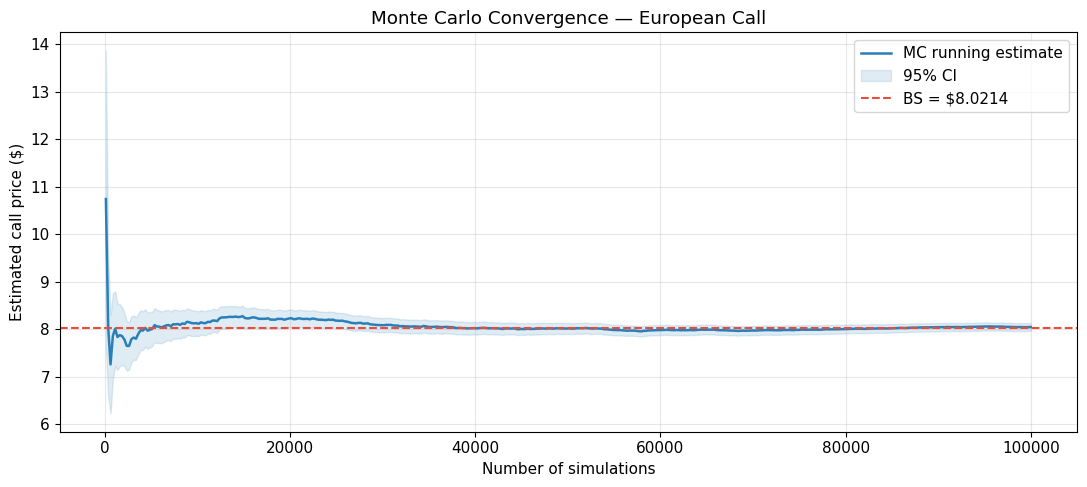

In [7]:
conv = convergence_analysis(terminal, K, r, T, 'call', n_points=400)

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(conv['n_sims'], conv['running_price'], lw=1.8, color='#2980B9', label='MC running estimate')
ax.fill_between(conv['n_sims'], conv['lower_ci'], conv['upper_ci'],
                alpha=0.15, color='#2980B9', label='95% CI')
ax.axhline(bs_call, color='#E74C3C', ls='--', lw=1.5, label=f'BS = ${bs_call:.4f}')

ax.set_xlabel('Number of simulations')
ax.set_ylabel('Estimated call price ($)')
ax.set_title('Monte Carlo Convergence — European Call')
ax.legend()
plt.tight_layout()
plt.savefig('../plots/convergence.png', dpi=150, bbox_inches='tight')
plt.show()


The confidence interval narrows at rate $\mathcal{O}(1/\sqrt{N})$, and the running mean oscillates around the true Black–Scholes price. By $N \approx 10{,}000$, the estimate is within \$0.10 of the analytical value.

## 6. Portfolio Value-at-Risk Simulation

We now treat the simulated terminal prices as outcomes for a simple equity portfolio and compute risk metrics from the resulting return distribution.


In [8]:
returns = simulate_portfolio_returns(terminal, S0)

print(f"Return distribution summary:")
print(f"  Mean:     {returns.mean():.4%}")
print(f"  Std dev:  {returns.std():.4%}")
print(f"  Skewness: {pd.Series(returns).skew():.4f}")
print(f"  Kurtosis: {pd.Series(returns).kurtosis():.4f}")
print(f"  Min:      {returns.min():.4%}")
print(f"  Max:      {returns.max():.4%}")


Return distribution summary:
  Mean:     5.1672%
  Std dev:  21.3266%
  Skewness: 0.6426
  Kurtosis: 0.8003
  Min:      -64.5083%
  Max:      160.4355%


### 6.1 VaR and Expected Shortfall

In [9]:
summary = compute_risk_summary(returns, portfolio_value, [0.90, 0.95, 0.99])

rows = []
for cl, v in summary.items():
    rows.append({
        'Confidence': f'{cl:.0%}',
        'VaR (%)': f"{v['VaR_pct']:.2%}",
        'VaR ($)': f"${v['VaR_dollar']:,.0f}",
        'ES (%)': f"{v['ES_pct']:.2%}",
        'ES ($)': f"${v['ES_dollar']:,.0f}",
    })
df_risk = pd.DataFrame(rows)
print(df_risk.to_string(index=False))


Confidence VaR (%)  VaR ($) ES (%)   ES ($)
       90%  20.22% $202,194 27.22% $272,177
       95%  25.86% $258,556 31.58% $315,768
       99%  35.19% $351,929 39.30% $393,024


### 6.2 Return Distribution with Risk Thresholds

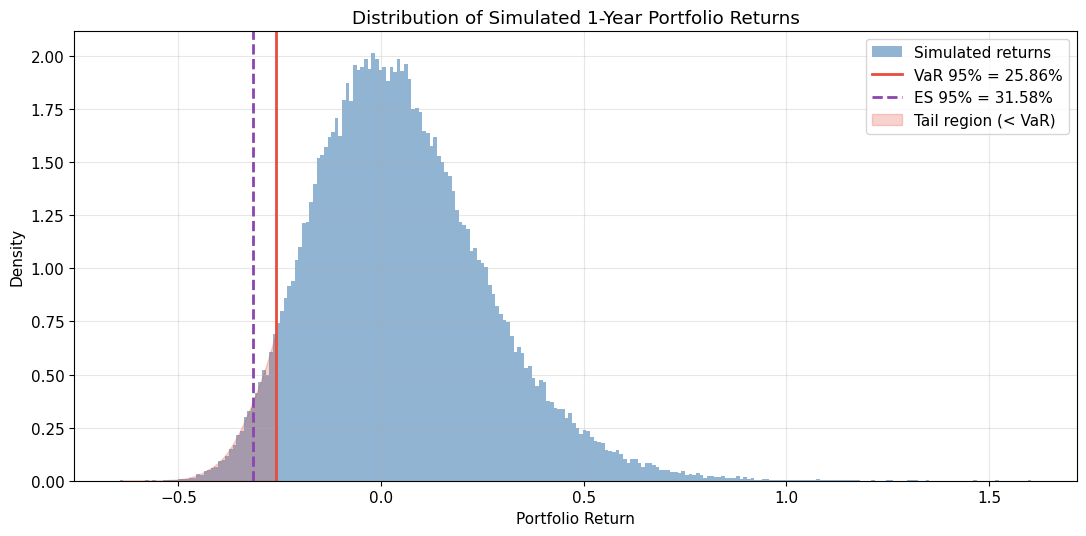

In [10]:
var95 = historical_var(returns, 0.95)
es95  = historical_expected_shortfall(returns, 0.95)

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.hist(returns, bins=250, density=True, alpha=0.6, color='steelblue', edgecolor='none',
        label='Simulated returns')

ax.axvline(-var95, color='#E74C3C', lw=2, label=f'VaR 95% = {var95:.2%}')
ax.axvline(-es95, color='#8E44AD', lw=2, ls='--', label=f'ES 95% = {es95:.2%}')

# Shade the tail
x_fill = np.linspace(returns.min(), -var95, 500)
from scipy.stats import gaussian_kde
kde = gaussian_kde(returns)
ax.fill_between(x_fill, kde(x_fill), alpha=0.25, color='#E74C3C', label='Tail region (< VaR)')

ax.set_xlabel('Portfolio Return')
ax.set_ylabel('Density')
ax.set_title('Distribution of Simulated 1-Year Portfolio Returns')
ax.legend()
plt.tight_layout()
plt.savefig('../plots/return_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Additional Visualisations

### 7.1 VaR and ES as a Function of Confidence Level


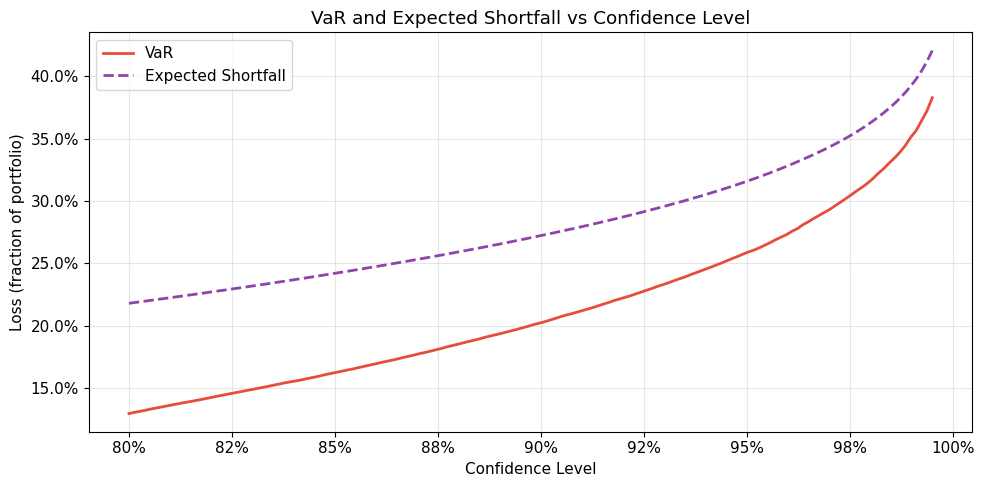

In [11]:
confidence_levels = np.linspace(0.80, 0.995, 150)
var_curve = [historical_var(returns, c) for c in confidence_levels]
es_curve  = [historical_expected_shortfall(returns, c) for c in confidence_levels]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(confidence_levels, var_curve, lw=2, color='#E74C3C', label='VaR')
ax.plot(confidence_levels, es_curve, lw=2, color='#8E44AD', ls='--', label='Expected Shortfall')
ax.set_xlabel('Confidence Level')
ax.set_ylabel('Loss (fraction of portfolio)')
ax.set_title('VaR and Expected Shortfall vs Confidence Level')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
ax.legend()
plt.tight_layout()
plt.savefig('../plots/var_visualisation.png', dpi=150, bbox_inches='tight')
plt.show()


### 7.2 Sensitivity — Option Price vs Volatility

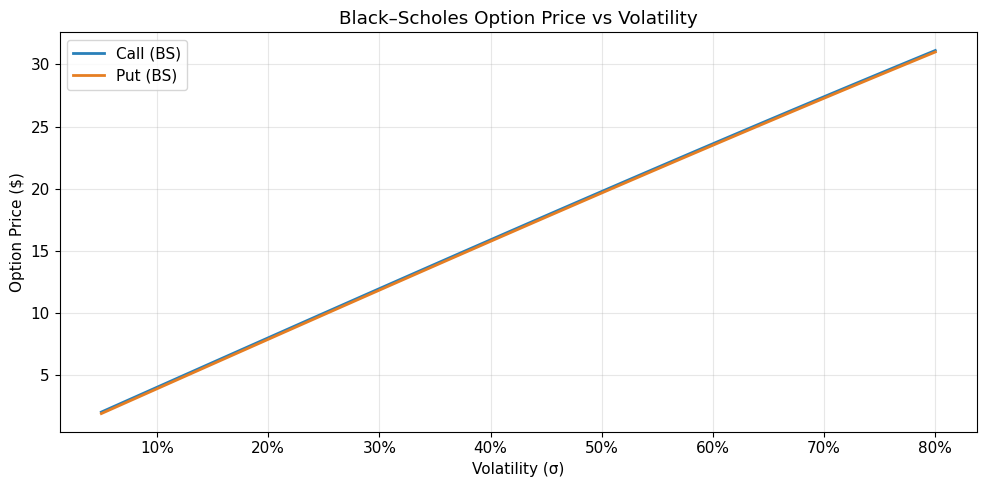

In [12]:
sigmas_range = np.linspace(0.05, 0.80, 80)
bs_calls = [black_scholes_call(S0, K, r, s, T) for s in sigmas_range]
bs_puts  = [black_scholes_put(S0, K, r, s, T) for s in sigmas_range]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sigmas_range, bs_calls, lw=2, color='#2980B9', label='Call (BS)')
ax.plot(sigmas_range, bs_puts, lw=2, color='#E67E22', label='Put (BS)')
ax.set_xlabel('Volatility (σ)')
ax.set_ylabel('Option Price ($)')
ax.set_title('Black–Scholes Option Price vs Volatility')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend()
plt.tight_layout()
plt.show()


## Summary

This notebook demonstrated a complete Monte Carlo pipeline for quantitative finance:

1. **GBM path simulation** — vectorised generation of 100,000 price paths.
2. **Option pricing** — MC estimates converging to the Black–Scholes benchmark within the expected standard error.
3. **Risk measurement** — VaR and Expected Shortfall computed from the full simulated return distribution, with confidence-level sensitivity analysis.

The modular code in `src/` can be extended to stochastic volatility models (Heston), jump-diffusion (Merton), exotic payoffs, and multi-asset portfolios with correlated dynamics.
